# Validation KUL20 new

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import scipy
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# PlatoSim libraries
import platosim.plot      as pt
import platosim.utilities as ut
from platosim.simfile      import SimFile
from platosim.simulation   import Simulation
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_paper
setup_paper()

In [3]:
path = '/lhome/nicholas/software/workdir/kul20_new'

---
## Camera level
---

### NSR from single quarter light curve

In [4]:
lcs = LightCurve(f'{path}/nsr/000000001', mode='multi')

In [5]:
lc = LightCurve(lcs.files("hdf5")[0])

In [6]:
lc.get_nsr(), lc.get_nsr_new()

(126.51942601385493, 139.9886187899033)

<IPython.core.display.Javascript object>


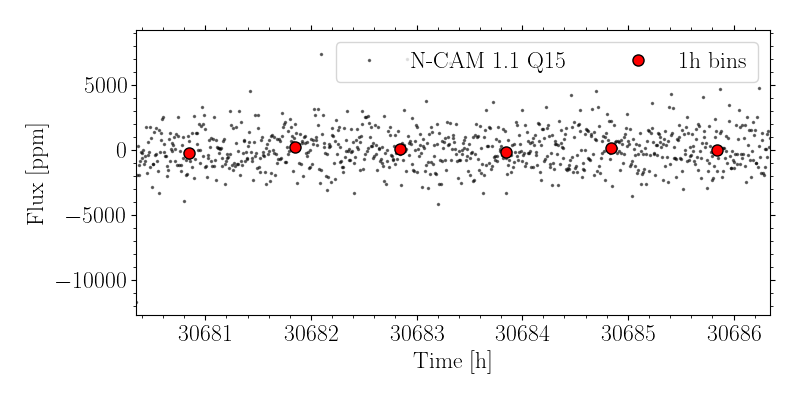

In [7]:
fig, ax = lc.plot(time_unit="h", flux_unit='ppm', binsize=1, alpha=0.5, figsize=(8,4));

### NSR limit from PINE

PINE (systematic) jitter noise:
- 25s BOL (EOL): 108 ppm
- 01h BOL (EOL): 9 ppm

In [32]:
NSR_jitter0 = ut.getJitterNoiseLimitNSR(0.054, tdur=25,   camType='normal')
NSR_jitter1 = ut.getJitterNoiseLimitNSR(0.054, tdur=3600, camType='normal')
NSR_jitter2 = ut.getJitterNoiseLimitNSR(0.040, tdur=3600, camType='normal')
NSR_jitter0, NSR_jitter1, NSR_jitter2

(108.0, 9.0, 6.666666666666666)

PINE (random) photon noise 1h:
- 01 N-CAM (BOL, EOL) = (388.5, 490.2) ppm
- 24 N-CAM (BOL, EOL) = (44.3, 49.3) ppm

In [39]:
NSR_photon0 = ut.getPhotonNoiseLimitNSR(11, passband='P', camType='normal', ncam=1,  ntra=1, tdur=3600)
NSR_photon1 = ut.getPhotonNoiseLimitNSR(11, passband='P', camType='normal', ncam=24, ntra=1, tdur=3600)
NSR_photon0, NSR_photon1

(262.0376810736823, 53.48821766772287)

Sky and read noise per 1h:
-  1 N-CAM BOL (EOL): () ppm
- 24 N-CAM BOL (EOL): () ppm

### NSR for all cameras

In [72]:
ofile_ncam = f'{path}/nsr_per_ncam_Q15.ftr'

# Compute NSR per camera
lcs = LightCurve(f'{path}/nsr', 'multi')
lcs.get_nsr_per_camera(ofile_ncam, suffix='hdf5', quarter=15)

# Load results and add Vmag
df = pd.read_feather(ofile_ncam)
df['Pmag'] = df.mag
df['Teff'] = np.ones_like(df.mag) * 6000
df['Vmag'] = ut.passbandConversionV2P(df.mag, df.Teff, inverse=True, method='fialho')
df.head()

100%|██████████████████████████████████████████████████| 1000/1000 [02:41<00:00,  6.19it/s]          


,index,ID,PIC,ra,dec,mag,group,camera,quarter,ccd,...,yCCD,rOA,xFP,yFP,ncon,SPR,NSR,Pmag,Teff,Vmag
0,0,1,2391499000005,80.607523,-31.452083,9.69412,1,2,15,2,...,1766.321185,11.777123,-50.686219,-9.702416,0,0.0,134.511047,9.69412,6000.0,10.040025
1,0,1,2391499000005,80.607523,-31.452083,9.69412,1,3,15,2,...,1769.116427,11.761951,-50.635904,-9.601082,0,0.0,138.030075,9.69412,6000.0,10.040025
2,0,1,2391499000005,80.607523,-31.452083,9.69412,1,4,15,2,...,1770.895338,11.754474,-50.603884,-9.589049,0,0.0,138.578781,9.69412,6000.0,10.040025
3,0,1,2391499000005,80.607523,-31.452083,9.69412,1,5,15,2,...,1775.245094,11.735547,-50.525588,-9.544041,0,0.0,133.061401,9.69412,6000.0,10.040025
4,0,1,2391499000005,80.607523,-31.452083,9.69412,1,6,15,2,...,1770.545081,11.755826,-50.610189,-9.588504,0,0.0,135.107590,9.69412,6000.0,10.040025


<IPython.core.display.Javascript object>


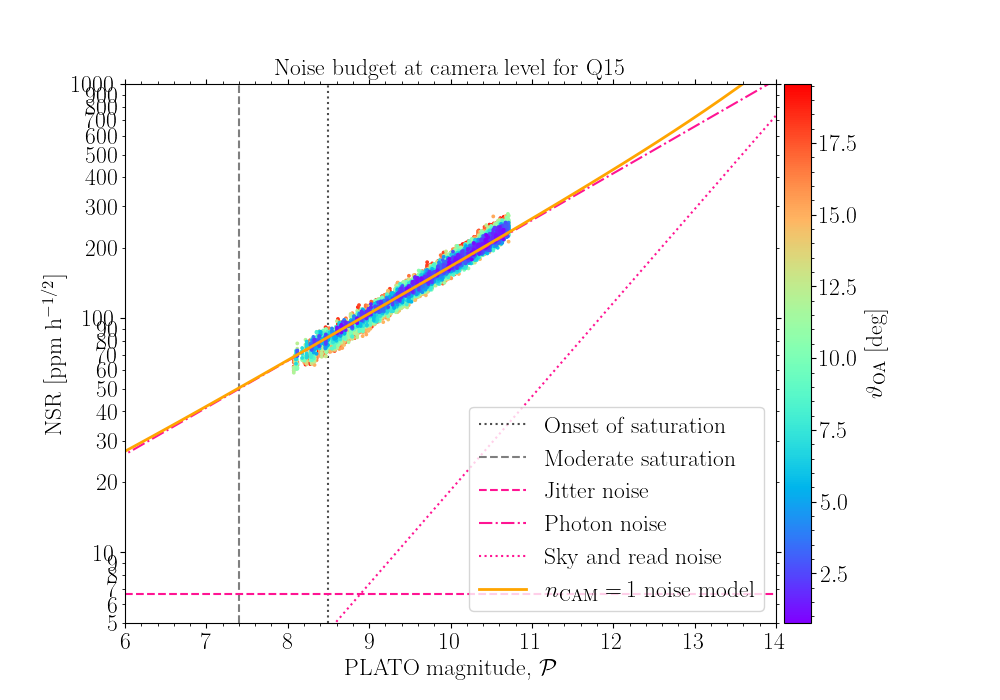

In [73]:
# Order after contaminants
df['mag'] = df.Pmag
col = 'rOA'
df = df.sort_values(by=[col], ascending=False)
# df = df[df.SPR < 0.06]

# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df, 
                                column=col, 
                                passband='P', 
                                show_ncam_noise_limits=1, 
                                show_saturation_limits=True,
                                legend=True, 
                                figsize=(10, 7))
# Settings
ax.set_title('Noise budget at camera level for Q15')
ax.set_xlim(6, 14)
ax.set_ylim(5, 1000)
# ax.set_xlim(8.3, 11.1)
# ax.set_ylim(50, 400)
plt.legend(loc='lower right');

---
## NSR at mission level
---

### Test NSR estimate

In [44]:
lcs = LightCurve(f'{path}/nsr/000000001', mode='multi')

<IPython.core.display.Javascript object>


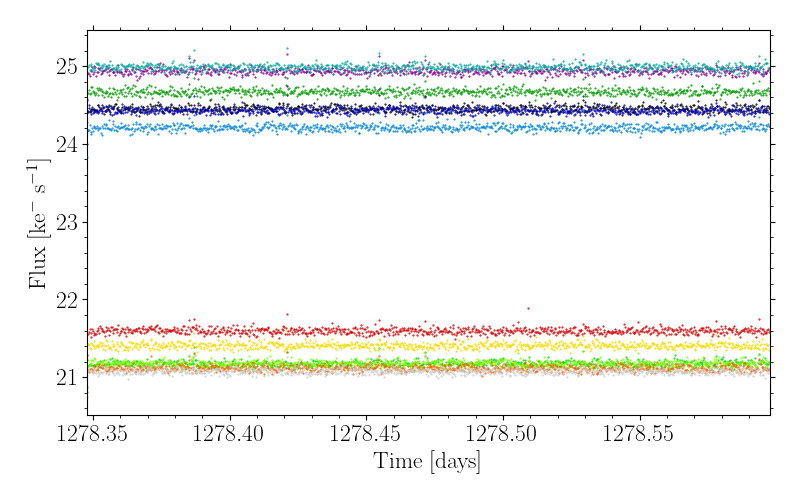

In [45]:
fig, ax = lcs.plot_multi(suffix='hdf5', alpha=1);

In [46]:
lc = lcs.merge(suffix='hdf5', flux_normalise=True, flux_group_mean=True)

Processing star ID 000000001
-------------------------------------------------------
Merging 12 light curves


100%|██████████████████████████████████████████████████| 12/12 [00:00<00:00, 242.91it/s]             

Sorting data after timings
Averaging data from same camera group
Done!
-------------------------------------------------------


In [47]:
lc.stat_sim_table().iloc[0]

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00, 37.00it/s]                


ID                     1
PIC        2391499000005
ra             80.607523
dec           -31.452083
mag              9.69412
group                  1
camera                 1
quarter               15
ccd                    2
xCCD          468.652282
yCCD         1761.856171
rOA            11.796023
xFP           -50.766589
yFP            -9.735741
ncon                   0
SPR                  0.0
Name: 0, dtype: object

<IPython.core.display.Javascript object>


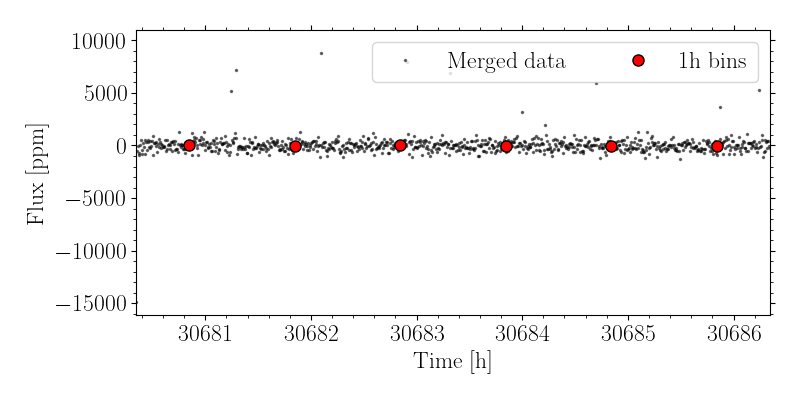

In [48]:
fig, ax = lc.plot(time_unit="h", flux_unit='ppm', binsize=1, alpha=0.5, figsize=(8,4));

In [49]:
lc.get_nsr(), lc.get_nsr_new(), lc.bin().std().flux * 1e6

(72.5685048655037, 39.527302415517575, 40.610419485482275)

<IPython.core.display.Javascript object>


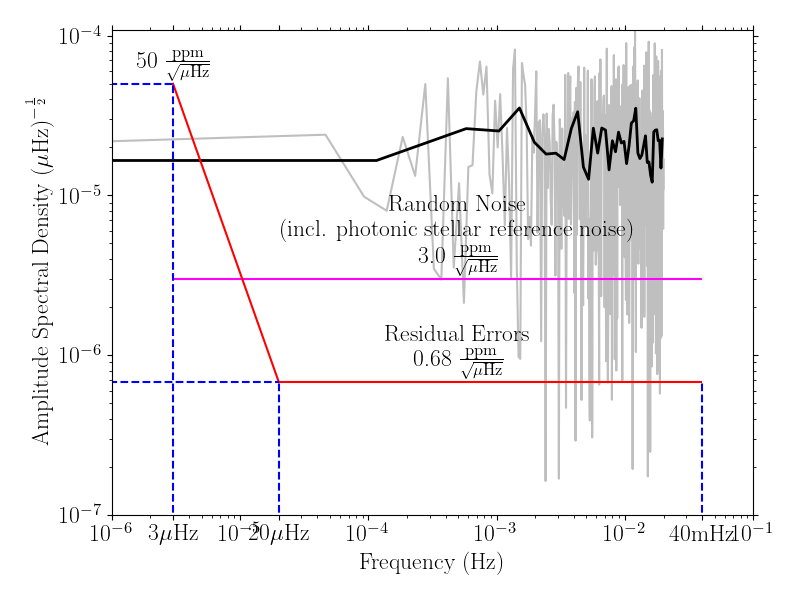

In [50]:
lc.plot_frequency_performance(figsize=(8,6));

### For all stars

In [78]:
# Filename
ofile_star = f'{path}/nsr_per_star_Q15.ftr'

# Compute NSR per star
lcs = LightCurve(f'{path}/nsr', 'multi')
lcs.get_nsr_per_star(ofile_star, suffix='hdf5', quarter=15);

# Load results and add Vmag
df = pd.read_feather(ofile_star)
df['Pmag'] = df.mag
df['Teff'] = np.ones_like(df.shape[0]) * 6000
df['Vmag'] = ut.passbandConversionV2P(df.mag, df.Teff, inverse=True, method='fialho')
df.head()

100%|██████████████████████████████████████████████████| 1000/1000 [01:51<00:00,  8.97it/s]          


,index,ID,mag,rOA,ncon,SPR,ncam,NSR,Pmag,Teff,Vmag
0,0,1,9.69412,15.635767,0,0.0,12,40.621017,9.69412,6000,10.040024
1,0,2,9.39890,17.693287,0,0.0,12,36.581210,9.39890,6000,9.744804
2,0,3,8.77547,11.048110,0,0.0,12,25.702376,8.77547,6000,9.121374
3,0,4,8.51543,11.790345,0,0.0,12,23.486389,8.51543,6000,8.861334
4,0,5,9.69817,13.011891,0,0.0,12,42.208552,9.69817,6000,10.044074


In [32]:
# df = pd.read_feather(ofile_ncam)
# ids = df.ID.unique()
# NSR = np.zeros(len(ids))
# for i in ids:
#     dx = df[df.ID == i]
#     NSR[i-1] = dx.NSR.mean() / np.sqrt(dx.shape[0])
# df['NSR'] = NSR

<IPython.core.display.Javascript object>


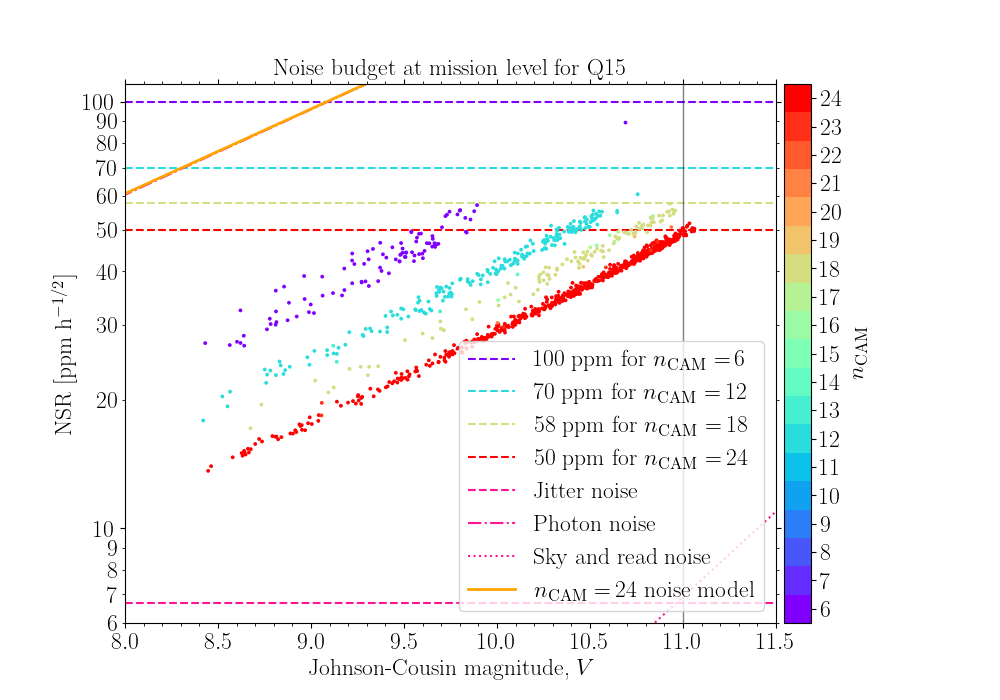

In [81]:
# Order after contaminants
col = 'ncam'
df['mag'] = df.Vmag
df = df.sort_values(by=[col], ascending=False)

# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df, 
                                column=col, 
                                passband='V', 
                                residuals="multi",
                                show_targets=True,
                                show_ncam_noise_limits=24, 
                                figsize=(10, 7))
ax.set_title('Noise budget at mission level for Q15')
ax.set_xlim(8, 11.5)
ax.set_ylim(6, 110)
# ax.set_xlim(6, 14)
# ax.set_ylim(5, 500)
plt.legend();

In [276]:
df[(df.ncam == 24) & (df.mag > 10.99) & (df.mag < 11.01)]

,index,ID,mag,rOA,ncon,SPR,ncam,NSR,Teff
449,0,450,11.002504,10.067398,0,0.0,24,49.397862,6000.0
535,0,536,11.003804,11.272206,0,0.0,24,49.607140,6000.0
609,0,610,10.996804,11.360944,0,0.0,24,50.600517,6000.0
591,0,592,10.998204,12.726155,0,0.0,24,51.256550,6000.0
794,0,795,11.005004,10.344023,0,0.0,24,49.226233,6000.0
301,0,302,11.000704,12.883781,0,0.0,24,51.389665,6000.0


In [139]:
ut.passbandConversionV2P(10.72, 6000, inverse=True)

11.065904

### Test NSR estimate

In [88]:
lcs = LightCurve(f'{path}/run_long', mode='multi')

In [89]:
# fig, ax = lcs.plot_multi(suffix='hdf5', alpha=1);

In [131]:
lc = lcs.merge(suffix='hdf5', 
               detrend=True,
               flux_normalise=False, 
               flux_group_mean=True)

Processing star ID 000001245
-------------------------------------------------------
Merging 24 light curves


100%|██████████████████████████████████████████████████| 24/24 [00:09<00:00,  2.


Sorting data after timings
Averaging data from same camera group
Done!
-------------------------------------------------------


In [113]:
# lc.stat_sim_table().iloc[0]

<IPython.core.display.Javascript object>


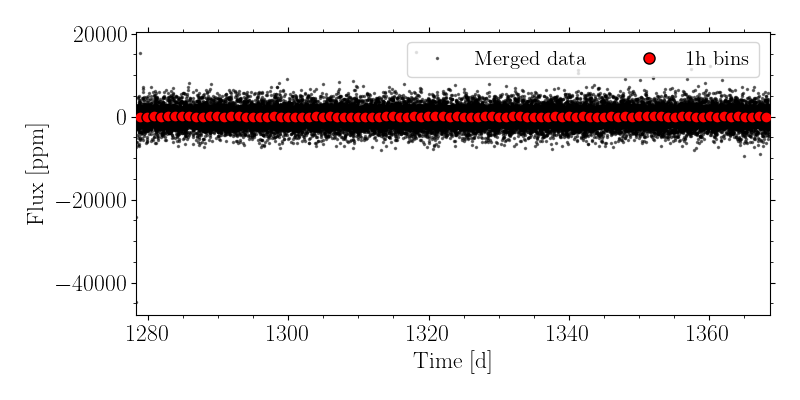

In [132]:
fig, ax = lc.plot(time_unit="d", flux_unit='ppm', binsize=1, alpha=0.5, figsize=(8,4));

In [136]:
lc.get_nsr()

52.282055869324324

<IPython.core.display.Javascript object>


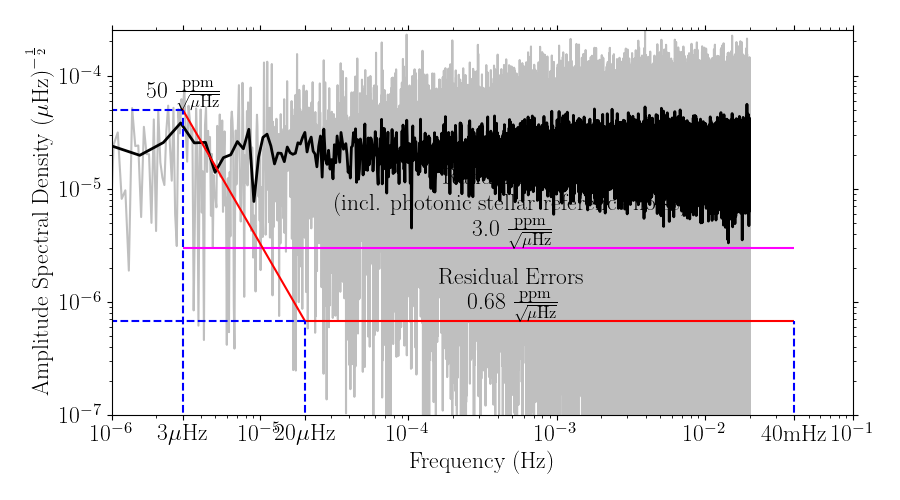

In [138]:
lc.plot_frequency_performance(figsize=(9,5));